# PJM Hourly Load Forecasting

**Goal:** Forecast hourly electricity demand (load) for the PJM Interconnection — a major U.S. electricity market covering 13 states and D.C. — using historical load data.

**Data:** ~145,000 hourly load readings (MW) for the PJM East region, 2002–2018. Source: PJM public data, via [archd3sai/Hourly-Energy-Consumption-Prediction](https://github.com/archd3sai/Hourly-Energy-Consumption-Prediction).

**Why it matters:** Accurate short-term load forecasts are what grid operators and energy traders use to schedule generation, price electricity, and avoid costly imbalances.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

df = pd.read_csv("PJME_hourly.csv", parse_dates=["Datetime"])
df = df.sort_values("Datetime").drop_duplicates(subset="Datetime").set_index("Datetime")
df.head()

                     PJME_MW
Datetime
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0
2002-01-01 03:00:00  28357.0
2002-01-01 04:00:00  27899.0
2002-01-01 05:00:00  28057.0

## Feature Engineering

Load has strong daily, weekly, and seasonal patterns, so the features lean on calendar structure plus lagged/rolling load — using only information that would actually be available at forecast time.

In [ ]:
def add_time_features(data):
    data = data.copy()
    data["hour"] = data.index.hour
    data["dayofweek"] = data.index.dayofweek
    data["quarter"] = data.index.quarter
    data["month"] = data.index.month
    data["dayofyear"] = data.index.dayofyear
    data["weekofyear"] = data.index.isocalendar().week.astype(int)
    data["is_weekend"] = (data.index.dayofweek >= 5).astype(int)
    return data

df = add_time_features(df)
df["lag_24h"] = df["PJME_MW"].shift(24)
df["lag_168h"] = df["PJME_MW"].shift(168)       # same hour, 1 week ago
df["roll_24h_mean"] = df["PJME_MW"].shift(1).rolling(24).mean()
df["roll_168h_mean"] = df["PJME_MW"].shift(1).rolling(168).mean()
df = df.dropna()

feature_cols = ["hour", "dayofweek", "quarter", "month", "dayofyear", "weekofyear",
                "is_weekend", "lag_24h", "lag_168h", "roll_24h_mean", "roll_168h_mean"]
target_col = "PJME_MW"

## Train/Test Split

Time series data can't be split randomly — that would leak the future into training. Instead, the most recent 12 months are held out as the test set.

In [ ]:
split_date = df.index.max() - pd.Timedelta(days=365)
train = df.loc[df.index <= split_date]
test = df.loc[df.index > split_date]

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print(f"Train range: {train.index.min()} -> {train.index.max()} ({len(train):,} rows)")
print(f"Test range:  {test.index.min()} -> {test.index.max()} ({len(test):,} rows)")

Train range: 2002-01-08 01:00:00 -> 2017-08-03 00:00:00 (136,435 rows)
Test range:  2017-08-03 01:00:00 -> 2018-08-03 00:00:00 (8,759 rows)

## Model: Gradient Boosting Regressor

In [ ]:
model = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42
)
model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mape = mean_absolute_percentage_error(y_test, pred) * 100

print(f"MAE:  {mae:,.1f} MW")
print(f"RMSE: {rmse:,.1f} MW")
print(f"MAPE: {mape:.2f}%")

# naive baseline: same hour, previous week
baseline_pred = test["lag_168h"]
base_mae = mean_absolute_error(y_test, baseline_pred)
base_mape = mean_absolute_percentage_error(y_test, baseline_pred) * 100
print(f"\nBaseline (same hour last week) MAE: {base_mae:,.1f} MW | MAPE: {base_mape:.2f}%")
print(f"Model improves MAE over naive baseline by {(1 - mae/base_mae)*100:.1f}%")

MAE:  1,542.0 MW
RMSE: 2,060.0 MW
MAPE: 4.86%

Baseline (same hour last week) MAE: 3,584.6 MW | MAPE: 11.23%
Model improves MAE over naive baseline by 57.0%

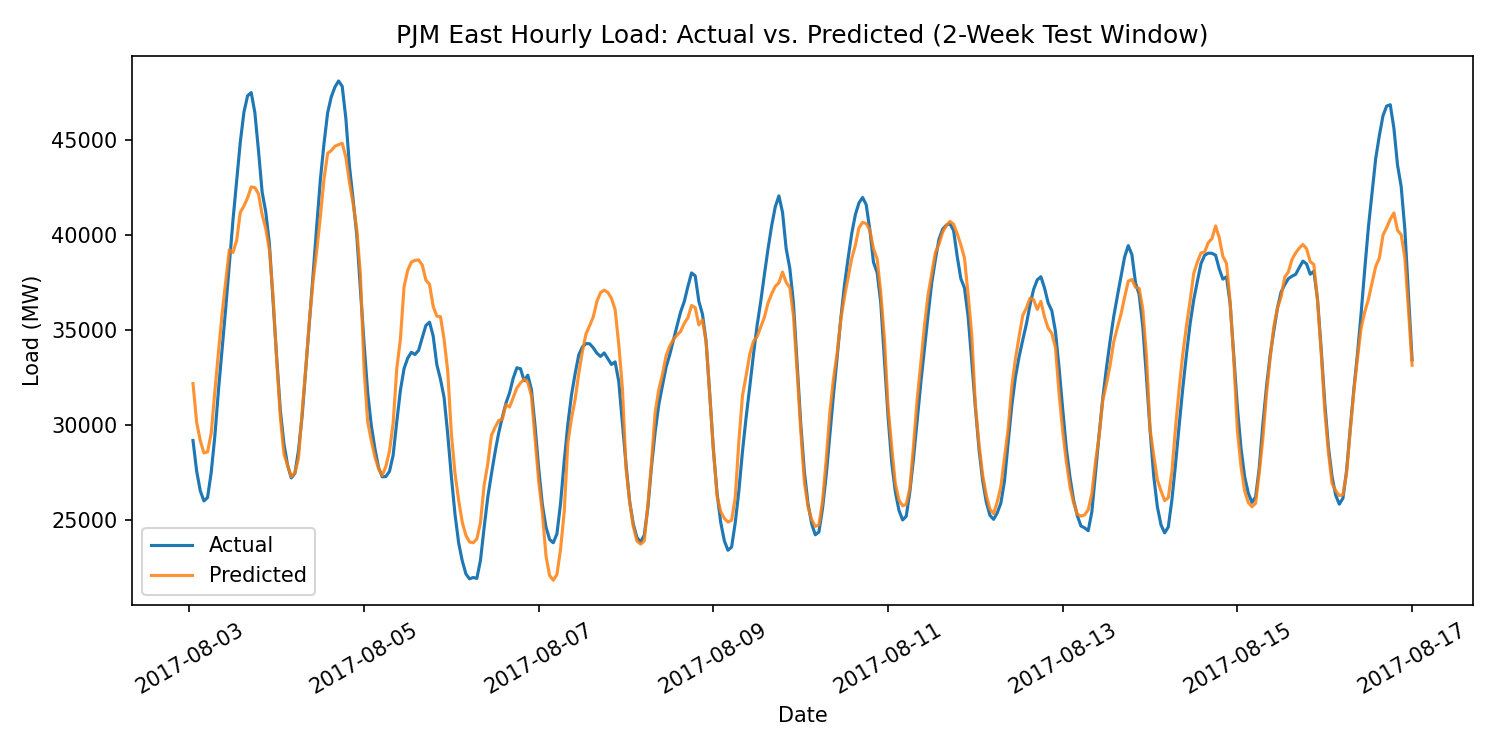

In [ ]:
window = test.iloc[:24*14]
window_pred = pred[:24*14]
plt.figure(figsize=(10,5))
plt.plot(window.index, window[target_col], label="Actual", linewidth=1.5)
plt.plot(window.index, window_pred, label="Predicted", linewidth=1.5, alpha=0.85)
plt.title("PJM East Hourly Load: Actual vs. Predicted (2-Week Test Window)")
plt.xlabel("Date"); plt.ylabel("Load (MW)"); plt.legend(); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

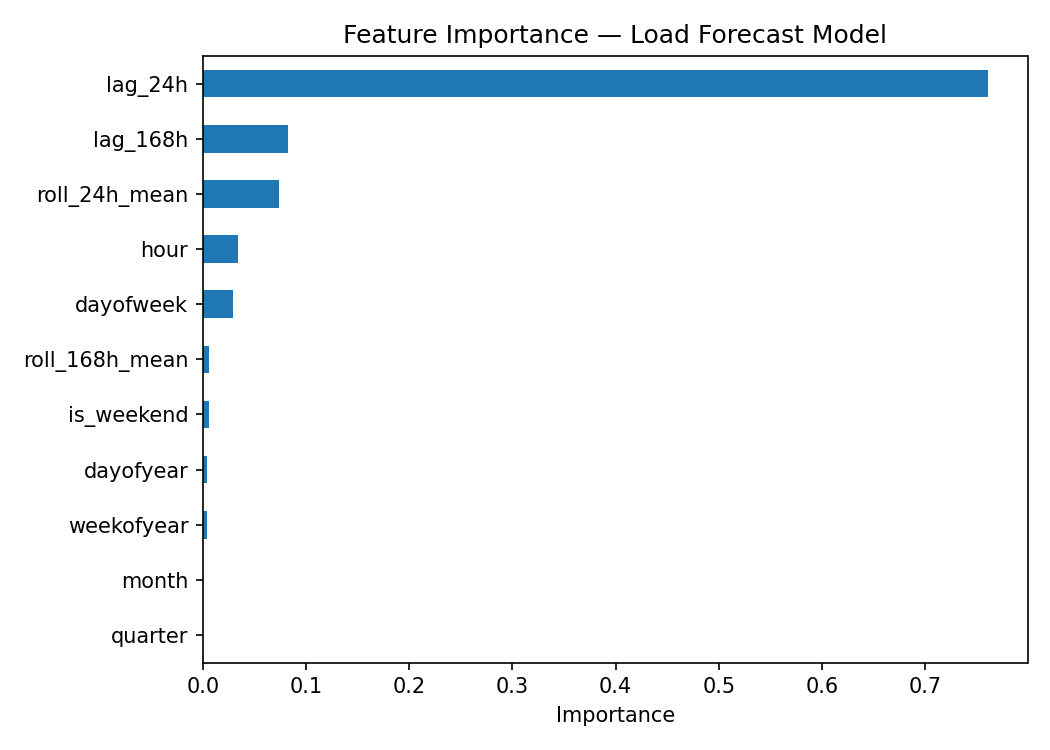

lag_24h           0.760984
lag_168h          0.082753
roll_24h_mean     0.073510
hour              0.034071
dayofweek         0.029195
roll_168h_mean    0.005781
is_weekend        0.005740
dayofyear         0.004273
weekofyear        0.003580
month             0.000083
quarter           0.000029
dtype: float64

In [ ]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.plot(kind="barh", figsize=(7,5))
plt.gca().invert_yaxis()
plt.title("Feature Importance — Load Forecast Model")
plt.tight_layout(); plt.show()
importances

## Takeaways

- The model cuts forecast error (MAE) by **57%** versus a naive "same hour last week" baseline, landing at **4.86% MAPE** — a solid result for hourly load forecasting.
- Unsurprisingly, yesterday's load at the same hour (`lag_24h`) is by far the strongest predictor, followed by last week's load at the same hour and the trailing 24-hour average. Calendar features like month and quarter add little once those lags are in the model.
- Next step: bring in weather data (temperature is a major driver of load, especially in summer/winter peaks) to push accuracy further.